In [ ]:
import os 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Definición de la ruta relativa dentro del repositorio
data_dir = "data"
data_path = os.path.join(data_dir, "melb_data.csv")

# Verificación y descarga automática en caso de ejecución en entornos efímeros (como Google Colab)
if not os.path.exists(data_path):
    os.makedirs(data_dir, exist_ok=True)
    print("Descargando dataset para asegurar reproducibilidad...")
    # URL del repositorio donde se alojará el archivo raw
    url = "https://raw.githubusercontent.com/tu_usuario/tu_repositorio/main/data/melb_data.csv"
    import urllib.request
    urllib.request.urlretrieve(url, data_path)

# Carga del dataset
data = pd.read_csv(data_path)
print(f"Dataset cargado exitosamente. Dimensiones: {data.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(data.shape)

(13580, 21)


In [ ]:
data.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,...,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,...,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  object 
 1   Address        13580 non-null  object 
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  object 
 4   Price          13580 non-null  float64
 5   Method         13580 non-null  object 
 6   SellerG        13580 non-null  object 
 7   Date           13580 non-null  object 
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  float64
 10  Bedroom2       13580 non-null  float64
 11  Bathroom       13580 non-null  float64
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  float64
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  object 
 17  Lattitude      13580 non-null  float64
 18  Longti

In [ ]:
data.dropna(inplace=True)
# Eliminar NAN

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6196 entries, 1 to 12212
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         6196 non-null   object 
 1   Address        6196 non-null   object 
 2   Rooms          6196 non-null   int64  
 3   Type           6196 non-null   object 
 4   Price          6196 non-null   float64
 5   Method         6196 non-null   object 
 6   SellerG        6196 non-null   object 
 7   Date           6196 non-null   object 
 8   Distance       6196 non-null   float64
 9   Postcode       6196 non-null   float64
 10  Bedroom2       6196 non-null   float64
 11  Bathroom       6196 non-null   float64
 12  Car            6196 non-null   float64
 13  Landsize       6196 non-null   float64
 14  BuildingArea   6196 non-null   float64
 15  YearBuilt      6196 non-null   float64
 16  CouncilArea    6196 non-null   object 
 17  Lattitude      6196 non-null   float64
 18  Longtitude  

In [ ]:
cols_cat = ['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'CouncilArea', 'Regionname']
#cols_cat = data.select_dtypes(include="object").columns
#cols_num = data.select_dtypes(exclude="object").columns

for col in cols_cat:
  print(f'Columna {col}: {data[col].nunique()} subniveles')

  # Todas las columnas tienen más de un subnivel

Columna Suburb: 287 subniveles
Columna Address: 6117 subniveles
Columna Type: 3 subniveles
Columna Method: 5 subniveles
Columna SellerG: 203 subniveles
Columna Date: 51 subniveles
Columna CouncilArea: 31 subniveles
Columna Regionname: 8 subniveles


In [ ]:
data.describe()
# No hay datos con una desviación estándar de cero, aunque la latitud y longitud (es decir, la ubicación o localización) es muy similar.

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,6196.000000,6.196000e+03,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000
mean,2.931407,1.068828e+06,9.751097,3101.947708,2.902034,1.576340,1.573596,471.006940,141.568645,1964.081988,-37.807904,144.990201,7435.489509
std,0.971079,6.751564e+05,5.612065,86.421604,0.970055,0.711362,0.929947,897.449881,90.834824,38.105673,0.075850,0.099165,4337.698917
min,1.000000,1.310000e+05,0.000000,3000.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1196.000000,-38.164920,144.542370,389.000000
25%,2.000000,6.200000e+05,5.900000,3044.000000,2.000000,1.000000,1.000000,152.000000,91.000000,1940.000000,-37.855438,144.926198,4383.750000
50%,3.000000,8.800000e+05,9.000000,3081.000000,3.000000,1.000000,1.000000,373.000000,124.000000,1970.000000,-37.802250,144.995800,6567.000000
75%,4.000000,1.325000e+06,12.400000,3147.000000,3.000000,2.000000,2.000000,628.000000,170.000000,2000.000000,-37.758200,145.052700,10175.000000
max,8.000000,9.000000e+06,47.400000,3977.000000,9.000000,8.000000,10.000000,37000.000000,3112.000000,2018.000000,-37.457090,145.526350,21650.000000


In [ ]:
print(f'Tamaño del set de datos antes de eliminar las filas repetidas: {data.shape}')
data.drop_duplicates(inplace=True)
print(f'Tamaño del set de datos después de eliminar las filas repetidas: {data.shape}')
# No se encontraron filas repetidas en los registros

Tamaño del set de datos antes de eliminar las filas repetidas: (6196, 21)
Tamaño del set de datos después de eliminar las filas repetidas: (6196, 21)


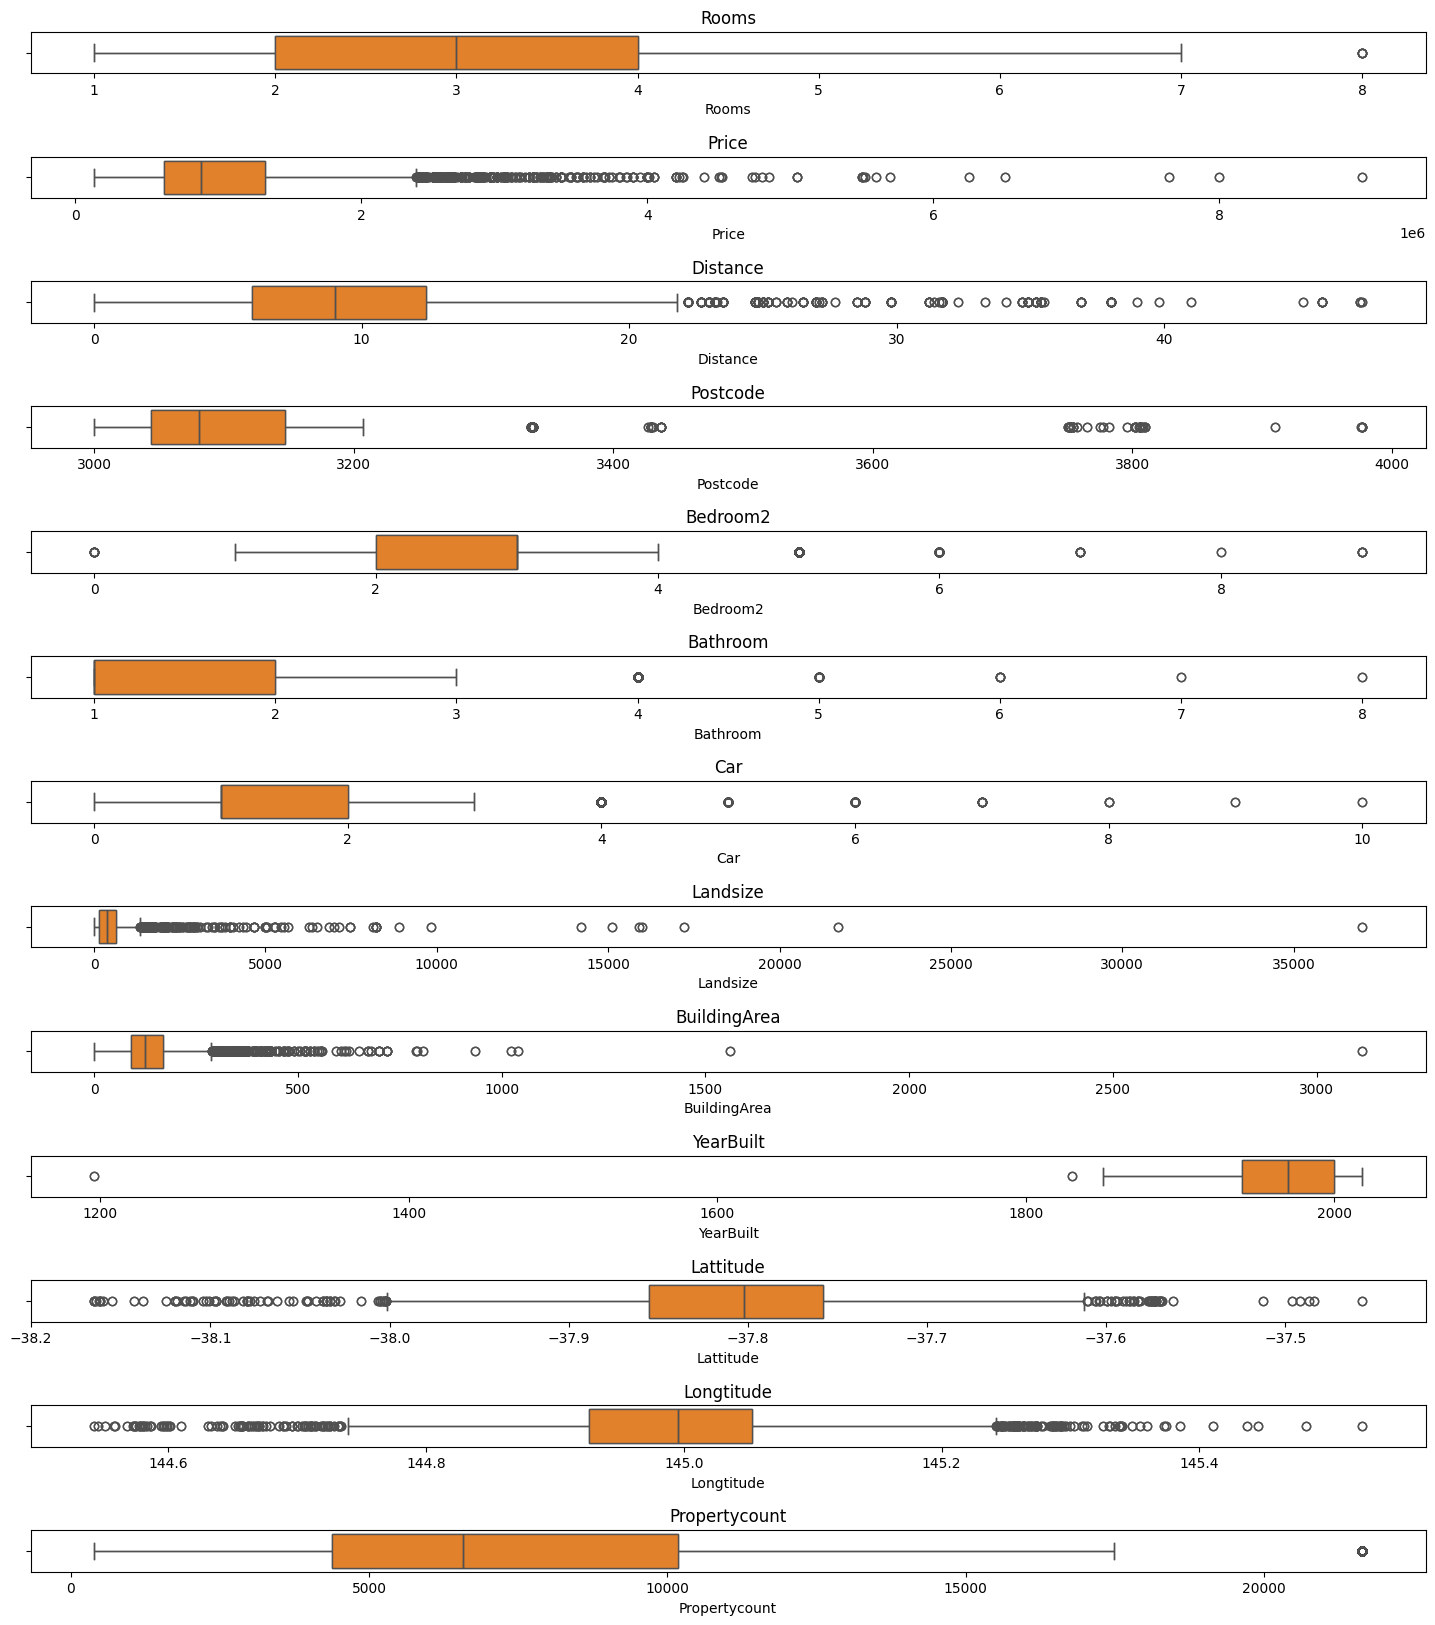

In [ ]:
cols_num = ['Rooms', 'Price', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car', 'Landsize', 'BuildingArea', 'YearBuilt', 'Lattitude', 'Longtitude', 'Propertycount']
#for col in cols_num:
#  print(f'Columna {col}: {data[col].nunique()} valores')

fig, ax = plt.subplots(nrows=13, ncols=1, figsize=(18, 20))
fig.subplots_adjust(hspace=2)
for i, col in enumerate(cols_num):
  sns.boxplot(x=col, data=data, ax=ax[i])
  sns.boxplot(data=data, x=col, ax=ax[i])
  ax[i].set_title(col)
  #ax[i].set_xlabel('')
  #ax[i].set_ylabel('')

Para las variables LANDSIZE y BUILDING AREA posiblemente existan valores extremos, aunque es posible que el tamaño del terreno y el área construida tengan esos valores.

In [ ]:
# print(f'Tamaño del set de datos ANTES de eliminar las filas con valores extremos: {data.shape}')
# data = data[data['Landsize']<= 25000]  En caso de querer eliminar los terrenos de tamaño menor a 25000
# print(f'Tamaño del set de datos DESPUÉS de eliminar las filas con valores extremos: {data.shape}')
# Se podría hacer lo mismo para otras variables, pero interpretando el significado de las variables, no parece ser necesario. No se encuentran valores incoherentes.

<ipython-input-52-88402dff2eb5>:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
<ipython-input-52-88402dff2eb5>:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
<ipython-input-52-88402dff2eb5>:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
<ipython-input-52-88402dff2eb5>:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)
<ipython-input-52-88402dff2eb5>:8: UserWarning: set_ticklabels() should only be used with a fixed nu

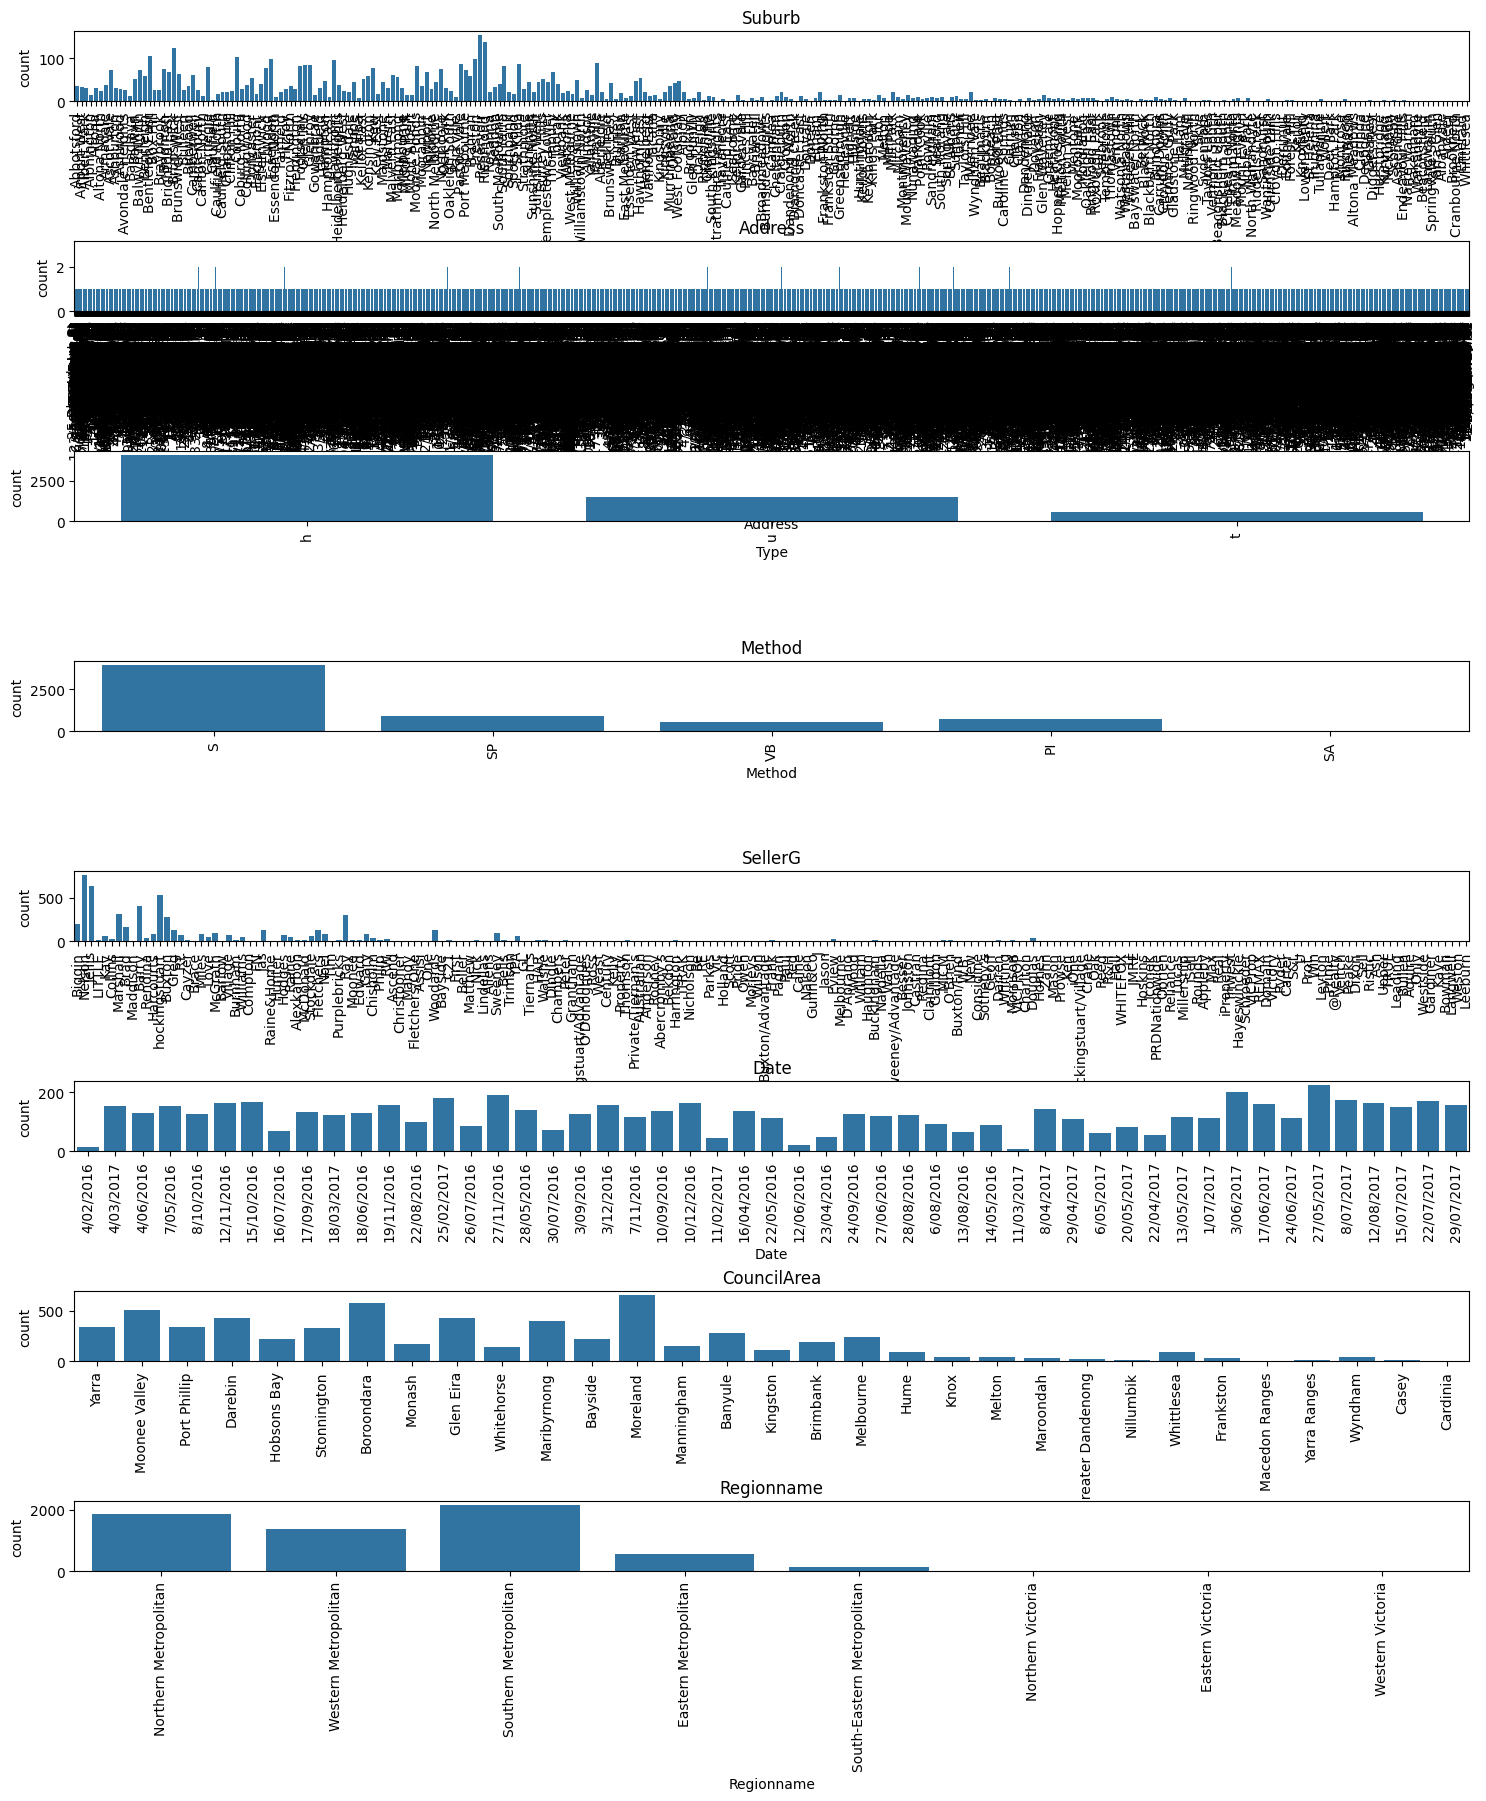

In [ ]:
cols_cat = ['Suburb', 'Address', 'Type', 'Method', 'SellerG', 'Date', 'CouncilArea', 'Regionname']

fig, ax = plt.subplots(nrows=8, ncols=1, figsize=(18, 20))
fig.subplots_adjust(hspace=2)
for i, col in enumerate(cols_cat):
  sns.countplot(x=col, data=data, ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xticklabels(ax[i].get_xticklabels(), rotation=90)